---
title: SAF Skyrmions Results
author: Orlando Dolores Morales
---

Some simulation results are shown with the same input as in the initial [notebook](saf_skyrmion.ipynb) with the only difference is the change in the spacer height and the cell size.
The first simulation was done with a really "big" spacer of 2 nm; however for a system Co-Ru-Co the value for the RKKY coefficient doesnt correspond to the value of the spacer used:

```{figure} ../images/ru-co-inter-coeff.png
:label: ru-co-rkky
:align: center
:width: 550 px

Coupling coefficient for Co/Ru/Co layers from [](doi:10.1103/physrevb.50.13505)
```
According to [](doi:10.1103/physrevb.50.13505) the value for the RKKY coefficient corresponding to $\sigma=-0.3 \, \text{mJ/m}^2$ should be for an spacer of around 0.8 nm, so this results are shown for an spacer of height 0.8 nm and cell size of 3x3x0.2 nm

The following script was used to create the images shown at the bottom of the notebook for the results of the simulation. 

```{literalinclude} ../scripts/saf_skyrmions_analysis.py
:linenos: 
:lineno-match:
```
The source code can be checked at the repo for [scripts](https://github.com/OrlandoDomo/micromagnetics/tree/main/scripts). The following cells show the topological phases obtained from the simulation. For visualization, one just has to click the button to use the binder server linked to this repo and use interactively this notebook.

## Simlation Results

Simulation results for the following conditions are shown:

- $K=0.1\times 10^{6}$ J/m$^3$
- $\sigma_{RKKY}=-0.3 \times 10^{-3}$ J/m$^2$
- $DMI=0.5\times 10^{-3}$ J/m$^2$

In [1]:
from IPython.display import display, Image

import ipywidgets as widgets
import os

In [3]:
Ds = range(150, 825, 75)
Mss = range(260, 460, 20)

image_options = {}
for D in Ds:
    for Ms in Mss:
        label = f'D={D} nm and Ms={Ms} kA/m'
        image_name = f'skyrmion-{D}nm-{Ms}kA_m.png'
        image_t_name = f'skyrmion-{D}nm-{Ms}kA_m-tranversal.png'
        
        image_options[label] = [image_name, image_t_name]

image_folder = "../images/saf_skyrmion-0.8nm-z_0.8nm-results"

def show_image_pair(option):
    image_files = image_options[option]
    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        display(Image(img_path, width=800))
        
widgets.interact(show_image_pair, option=list(image_options.keys()))

interactive(children=(Dropdown(description='option', options=('D=150 nm and Ms=260 kA/m', 'D=150 nm and Ms=280…

<function __main__.show_image_pair(option)>

For this simulation the phase diagram was plotted according to the topological constant $k$ for each field
![](../images/saf_skyrmion-0.8nm-z_0.8nm-results/phase_diagram.png)



Then the simulations were repeteaded, but now the value for DMI interaction was set to $DMI=1.0 \times 10^{-3}$ J/m$^2$

In [48]:
Ds = range(150, 750, 75)
Mss = range(260, 460, 20)

image_options = {}
for D in Ds:
    for Ms in Mss:
        label = f'D={D} nm,  Ms={Ms} kA/m'
        image_name = f'skyrmion-{D}nm-{Ms}kA_m.png'
        image_t_name = f'skyrmion-{D}nm-{Ms}kA_m-tranversal.png'
        
        image_options[label] = [image_name, image_t_name]

image_folder = "../images/saf_skyrmion-0.8nm-z_0.8nm-d_1-results"

def show_image_pair(option):
    image_files = image_options[option]
    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        try:
            display(Image(img_path, width=800))
        except:
            print('404')
        
widgets.interact(show_image_pair, option=list(image_options.keys()))

interactive(children=(Dropdown(description='option', options=('D=150 nm,  Ms=260 kA/m', 'D=150 nm,  Ms=280 kA/…

<function __main__.show_image_pair(option)>

For this simulation the phase diagram was plotted according to the topological constant $k$ for each field
![](../images/saf_skyrmion-0.8nm-z_0.8nm-d_1-results/phase_diagram.png)

We can plot the skyrmion size differences too for two 

In [41]:
radii_150nm = {
    260: 30,
    280: 30,
    300: 33,
    320: 36,
    340: 36,
    360: 39,
    380: 42,
    400: 45,
    420: 48,
    440: 51
}

radii_300nm = {
    260: 81,
    280: 87,
    300: 90,
    320: 93,
    340: 96,
    360: 96
}
radii_450nm = {
    260: 147,
    280: 156,
    300: 159,
    320: 162
}

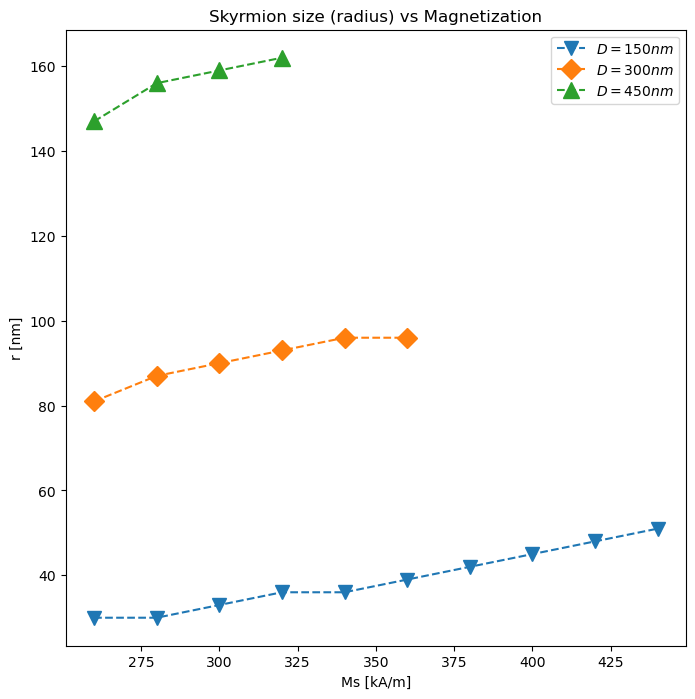

In [45]:
import matplotlib.pyplot as plt

magnetisation_values = range(260, 380, 20)

fig, ax = plt.subplots(figsize=(8,8))
ax.plot(radii_150nm.keys(), radii_150nm.values(), marker='v', ls='--', label=r'$D=150nm$', ms=10)
ax.plot(radii_300nm.keys(), radii_300nm.values(), marker='D', ls='--', label=r'$D=300nm$', ms=10)
ax.plot(radii_450nm.keys(), radii_450nm.values(), marker='^', ls='--', label=r'$D=450nm$', ms=12)
ax.set_xlabel('Ms [kA/m]')
ax.set_ylabel('r [nm]')
ax.set_title('Skyrmion size (radius) vs Magnetization')
ax.legend()


In [51]:
import micromagneticdata as md

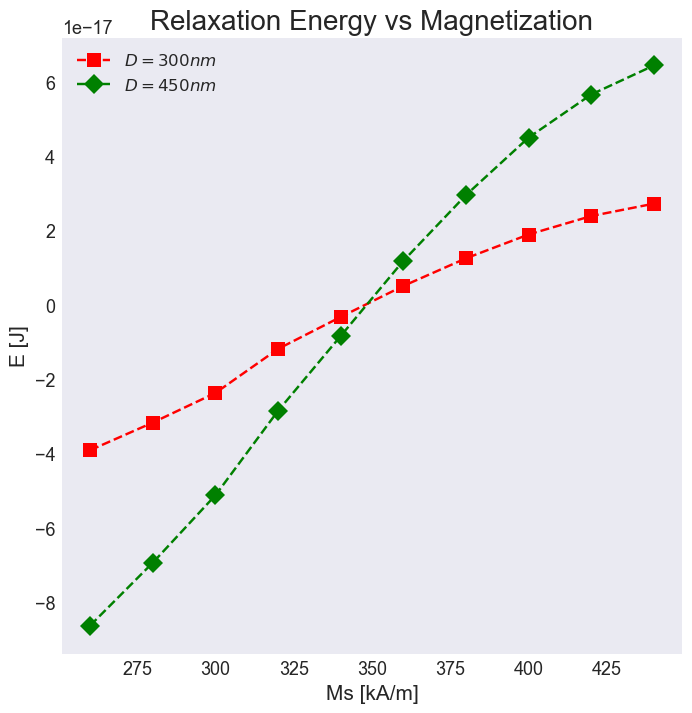

In [77]:


fig, ax = plt.subplots(figsize=(8,8))

options = {
    300: {
        'marker': 's',
        'color': 'r'
    },
    450: {
        'marker': 'D',
        'color': 'g'
    }
}

for D in [300, 450]:
    total_energy = {}
    for Ms in range(260, 460, 20):
        data = md.Data(name='saf_skyrmion', dirname=f'../results/saf_skyrmion-0.8nm/saf_skyrmion-{D}nm-{Ms}kA_m')
        total_energy[Ms] = data[0].table.data.E
    ax.plot(total_energy.keys(), total_energy.values(), marker=options[D]['marker'], c=options[D]['color'], ls='--', label=rf'$D={D}nm$', ms=10)

ax.set_xlabel('Ms [kA/m]')
ax.set_ylabel('E [J]')
ax.set_title('Relaxation Energy vs Magnetization')
ax.legend()

In [71]:
data[0].table.data.columns

Index(['max_mxHxm', 'E', 'delta_E', 'bracket_count', 'line_min_count',
       'conjugate_cycle_count', 'cycle_count', 'cycle_sub_count',
       'energy_calc_count', 'E_exchange', 'max_spin_ang_exchange',
       'stage_max_spin_ang_exchange', 'run_max_spin_ang_exchange', 'E_rkky',
       'E_uniaxialanisotropy', 'E_demag', 'DMI_Cnv_z:dmi:Energy', 'iteration',
       'stage_iteration', 'stage', 'mx', 'my', 'mz'],
      dtype='object')